# Test Set Predictions

This notebook generates predictions on `TEST_FINAL.csv` using the model artifact saved at the end of Block 3.

### What this is
A separate, dedicated notebook for inference on a held-out, unseen test set. Kept apart from the training notebook because:
- Training and inference are different concerns. Mixing them encourages accidental leakage.
- It validates that the saved model artifact actually works in a fresh environment — the same way the Flask app uses it.
- Re-running training to re-generate predictions would be wasteful.

### What we're predicting
- **22,265 rows** = 365 stores × 61 days
- **Dates: June 1 – July 31, 2019** (immediately after TRAIN.csv ends on May 31, 2019)
- **Forward-in-time forecasting** — the model predicts a future period it has never seen, exactly as a deployed system would

### What we're NOT doing
This is a feature-only test set with no `Sales` column, so we **cannot compute holdout metrics** here. Our reported MAPE of 20.90% comes from the chronological holdout we carved out of TRAIN.csv in Block 3 — that's still our best honest estimate of generalization error.

### One small but important note: `#Order` is correctly absent
TEST_FINAL.csv doesn't have a `#Order` column — and it shouldn't, since the number of orders on a future date isn't knowable. This validates Block 2's leakage rule: any model that used `#Order` as a feature would now be unable to make predictions, because the column simply doesn't exist at inference time.


---
## 1. Load model artifact and test data

In [ ]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Load saved artifact from Block 3
ARTIFACT_PATH = Path("artifacts/sales_forecast_model.joblib")
artifact = joblib.load(ARTIFACT_PATH)

MODEL = artifact["model"]
FEATURE_NAMES = artifact["feature_names"]
NUMERIC_FEATURES = artifact["numeric_features"]
CATEGORICAL_FEATURES = artifact["categorical_features"]
CATEGORICAL_VOCAB = artifact["categorical_vocab"]
MODEL_NAME = artifact["model_name"]
MODEL_METRICS = artifact["metrics"]

print(f"Loaded: {MODEL_NAME}")
print(f"Holdout metrics (from Block 3): {MODEL_METRICS}")
print(f"Expected feature order: {FEATURE_NAMES}")

Loaded: XGBoost (default)
Holdout metrics (from Block 3): {'MAE': 9676.027812807739, 'RMSE': np.float64(14286.769796163466), 'MAPE': np.float64(20.901416260538443), 'R²': 0.5485240438297717}
Expected feature order: ['Store_id', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Holiday', 'Discount_bin', 'Store_Type', 'Location_Type', 'Region_Code']


In [ ]:
# Load test set
test = pd.read_csv("TEST_FINAL.csv", parse_dates=["Date"])
print(f"Test set shape: {test.shape}")
print(f"Date range: {test['Date'].min().date()} → {test['Date'].max().date()}")
print(f"Stores: {test['Store_id'].nunique()}")
test.head()

Test set shape: (22265, 8)
Date range: 2019-06-01 → 2019-07-31
Stores: 365


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount
0,T1188341,171,S4,L2,R3,2019-06-01,0,No
1,T1188342,172,S1,L1,R1,2019-06-01,0,No
2,T1188343,173,S4,L2,R1,2019-06-01,0,No
3,T1188344,174,S1,L1,R4,2019-06-01,0,No
4,T1188345,170,S1,L1,R2,2019-06-01,0,No


---
## 2. Schema validation

Before predicting, we verify that every value in TEST_FINAL is something the model can handle. This catches data drift early — if a new `Store_Type` appeared, the model's encoder would silently produce nonsense.

In [ ]:
checks_passed = True

# Categorical values: every value must exist in the training vocabulary
for col in CATEGORICAL_FEATURES:
    test_vals = set(test[col].unique())
    train_vals = set(CATEGORICAL_VOCAB[col])
    new_vals = test_vals - train_vals
    if new_vals:
        print(f"  ⚠ {col}: unseen values {new_vals}")
        checks_passed = False
    else:
        print(f"  ✓ {col}: all values in training vocabulary")

# Required columns must exist
required = [
    "Store_id",
    "Store_Type",
    "Location_Type",
    "Region_Code",
    "Date",
    "Holiday",
    "Discount",
]
missing = [c for c in required if c not in test.columns]
if missing:
    print(f"  ⚠ Missing columns: {missing}")
    checks_passed = False
else:
    print(" ✓ All required columns present")

# No null values
n_null = test[required].isnull().sum().sum()
if n_null:
    print(f"  ⚠ {n_null} null values present")
    checks_passed = False
else:
    print(" ✓ No nulls")

print()
print(
    "All schema checks passed."
    if checks_passed
    else "FAILED — investigate before proceeding."
)

  ✓ Store_Type: all values in training vocabulary
  ✓ Location_Type: all values in training vocabulary
  ✓ Region_Code: all values in training vocabulary
  ✓ All required columns present
  ✓ No nulls

All schema checks passed.


---
## 3. Apply the same feature engineering used during training

This must be **identical** to Block 3 — same calendar features, same categorical encoding using the saved vocabulary. Any drift here silently corrupts predictions.

In [ ]:
def add_calendar_features(df, date_col="Date"):
    """Identical to Block 3 section 3."""
    df = df.copy()
    d = df[date_col]
    df["Year"] = d.dt.year
    df["Month"] = d.dt.month
    df["Day"] = d.dt.day
    df["DayOfWeek"] = d.dt.dayofweek
    df["DayOfYear"] = d.dt.dayofyear
    df["WeekOfYear"] = d.dt.isocalendar().week.astype(int)
    df["Quarter"] = d.dt.quarter
    df["IsWeekend"] = (d.dt.dayofweek >= 5).astype(int)
    df["IsMonthStart"] = d.dt.is_month_start.astype(int)
    df["IsMonthEnd"] = d.dt.is_month_end.astype(int)
    return df


test_features = add_calendar_features(test)
test_features["Discount_bin"] = (test_features["Discount"] == "Yes").astype(int)

# Encode categoricals using the SAVED training vocabulary
# This is the critical bit — using `pd.Categorical(..., categories=vocab)` ensures
# 'S1' encodes to whatever code it had during training, not just the alphabetical order.
for col in CATEGORICAL_FEATURES:
    vocab = CATEGORICAL_VOCAB[col]
    test_features[col] = pd.Categorical(test_features[col], categories=vocab).codes

# Subset and reorder to match training feature order EXACTLY
X_test = test_features[FEATURE_NAMES]

print(f"Feature matrix shape: {X_test.shape}")
print(f"Columns in correct order: {list(X_test.columns) == FEATURE_NAMES}")
X_test.head()

Feature matrix shape: (22265, 16)
Columns in correct order: True


,Store_id,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,Quarter,IsWeekend,IsMonthStart,IsMonthEnd,Holiday,Discount_bin,Store_Type,Location_Type,Region_Code
0,171,2019,6,1,5,152,22,2,1,1,0,0,0,3,1,2
1,172,2019,6,1,5,152,22,2,1,1,0,0,0,0,0,0
2,173,2019,6,1,5,152,22,2,1,1,0,0,0,3,1,0
3,174,2019,6,1,5,152,22,2,1,1,0,0,0,0,0,3
4,170,2019,6,1,5,152,22,2,1,1,0,0,0,0,0,1


---
## 4. Generate predictions

In [5]:
predictions = MODEL.predict(X_test)

# Sanity check the predictions
print(f"Predictions shape: {predictions.shape}")
print(f"Min:    {predictions.min():,.2f}")
print(f"Max:    {predictions.max():,.2f}")
print(f"Mean:   {predictions.mean():,.2f}")
print(f"Median: {np.median(predictions):,.2f}")

# Negative predictions would indicate a problem (Sales can't be negative)
n_negative = (predictions < 0).sum()
print(f"Negative predictions: {n_negative}  (any > 0 is a warning sign)")

Predictions shape: (22265,)
Min:    9,056.56
Max:    149,934.91
Mean:   44,863.21
Median: 41,689.32
Negative predictions: 0  (any > 0 is a warning sign)


In [6]:
# If any predictions are negative or zero, clip to a small positive value.
# This is a pragmatic post-processing step — the model has no built-in non-negativity
# constraint, but Sales is bounded below by 0 in reality.
predictions_clipped = np.clip(predictions, a_min=1.0, a_max=None)
n_clipped = (predictions != predictions_clipped).sum()
print(f"Predictions clipped to >= 1: {n_clipped}")

Predictions clipped to >= 1: 0


---
## 5. Build and save the submission file

We produce two outputs:
1. **`predictions.csv`** — minimal: `ID, Sales`. Standard Kaggle-style submission format.
2. **`predictions_full.csv`** — annotated: includes all input features alongside the prediction. Useful for debugging and for the technical blog (so readers can see what the model is doing).

In [ ]:
# Submission-style: ID + predicted Sales
submission = pd.DataFrame(
    {
        "ID": test["ID"],
        "Sales": predictions_clipped.round(2),
    }
)
submission.to_csv("predictions.csv", index=False)
print(f"Saved predictions.csv ({len(submission):,} rows)")
submission.head()

Saved predictions.csv (22,265 rows)


,ID,Sales
0,T1188341,73052.117188
1,T1188342,46341.558594
2,T1188343,89480.343750
3,T1188344,48163.480469
4,T1188345,47383.460938


In [ ]:
# Annotated version with all inputs
predictions_full = test.copy()
predictions_full["Predicted_Sales"] = predictions_clipped.round(2)
predictions_full["DayOfWeek_Name"] = test["Date"].dt.day_name()

predictions_full.to_csv("predictions_full.csv", index=False)
print(f"Saved predictions_full.csv ({len(predictions_full):,} rows)")
predictions_full.head()

Saved predictions_full.csv (22,265 rows)


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,Predicted_Sales,DayOfWeek_Name
0,T1188341,171,S4,L2,R3,2019-06-01,0,No,73052.117188,Saturday
1,T1188342,172,S1,L1,R1,2019-06-01,0,No,46341.558594,Saturday
2,T1188343,173,S4,L2,R1,2019-06-01,0,No,89480.343750,Saturday
3,T1188344,174,S1,L1,R4,2019-06-01,0,No,48163.480469,Saturday
4,T1188345,170,S1,L1,R2,2019-06-01,0,No,47383.460938,Saturday


---
## 6. Sanity check predictions against training distribution

A model can produce technically-valid output that's still nonsense — predictions that don't look like the kind of values it saw during training. We check by comparing prediction distributions to the actual Sales distribution from TRAIN.

In [ ]:
train_full = pd.read_csv("TRAIN.csv", parse_dates=["Date"])
train_full = train_full[train_full["Sales"] > 0]

print(f"{'':25} {'Train Sales':>15} {'Predictions':>15}")
print(f"{'-' * 55}")
for stat in ["mean", "median", "std", "min", "max"]:
    train_val = getattr(train_full["Sales"], stat)()
    pred_val = getattr(pd.Series(predictions_clipped), stat)()
    print(f"  {stat:25} {train_val:>15,.0f} {pred_val:>15,.0f}")
print()
for q in [0.1, 0.25, 0.75, 0.9]:
    train_val = train_full["Sales"].quantile(q)
    pred_val = pd.Series(predictions_clipped).quantile(q)
    print(f"  q={q:>4} percentile          {train_val:>15,.0f} {pred_val:>15,.0f}")

                              Train Sales     Predictions
-------------------------------------------------------
  mean                               42,789          44,863
  median                             39,678          41,689
  std                                18,453          16,913
  min                                   708           9,057
  max                               247,215         149,935

  q= 0.1 percentile                   23,448          26,319
  q=0.25 percentile                   30,429          32,816
  q=0.75 percentile                   51,909          53,825
  q= 0.9 percentile                   66,282          67,722


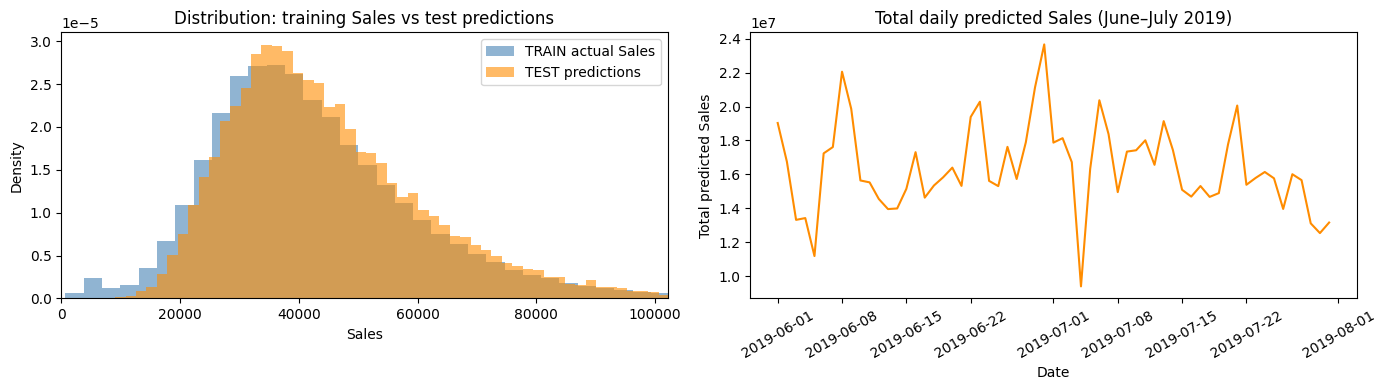

In [ ]:
# Visual comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(
    train_full["Sales"],
    bins=80,
    alpha=0.6,
    label="TRAIN actual Sales",
    color="steelblue",
    density=True,
)
axes[0].hist(
    predictions_clipped,
    bins=80,
    alpha=0.6,
    label="TEST predictions",
    color="darkorange",
    density=True,
)
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution: training Sales vs test predictions")
axes[0].legend()
axes[0].set_xlim(0, train_full["Sales"].quantile(0.99))

# Predictions over time — should show weekly pattern
daily_pred = (
    pd.DataFrame(
        {
            "Date": test["Date"],
            "Pred": predictions_clipped,
        }
    )
    .groupby("Date")["Pred"]
    .sum()
)

axes[1].plot(daily_pred.index, daily_pred.values, color="darkorange")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total predicted Sales")
axes[1].set_title("Total daily predicted Sales (June–July 2019)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**What to check in these plots:**
- Distributions should overlap substantially. If predictions cluster much tighter than training Sales, the model is being too conservative.
- The daily total should show a clear weekly pattern (peaks/troughs every 7 days). Flat output would suggest the day-of-week features aren't being used.


---
## 7. Aggregate predictions for the blog/demo

A few summary tables you can lift directly into your technical blog or Loom narration.

In [ ]:
# Predicted total revenue, June–July 2019
total_pred = predictions_clipped.sum()
print(f"Total predicted revenue (June–July 2019): ₹{total_pred:,.0f}")
print(f"Average daily revenue across chain: ₹{total_pred / 61:,.0f}")
print(f"Average daily revenue per store: ₹{total_pred / (61 * 365):,.0f}")

Total predicted revenue (June–July 2019): ₹998,879,424
Average daily revenue across chain: ₹16,375,073
Average daily revenue per store: ₹44,863


In [ ]:
# By store type
by_type = (
    predictions_full.groupby("Store_Type")
    .agg(
        n_predictions=("Predicted_Sales", "count"),
        total_predicted=("Predicted_Sales", "sum"),
        mean_predicted=("Predicted_Sales", "mean"),
    )
    .round(0)
)
by_type

,n_predictions,total_predicted,mean_predicted
Store_Type,,,
S1,10492,413327712.0,39395.0
S2,3416,97292920.0,28482.0
S3,2928,143966160.0,49169.0
S4,5429,344292608.0,63417.0


In [ ]:
# By region
by_region = (
    predictions_full.groupby("Region_Code")
    .agg(
        n_stores=("Store_id", "nunique"),
        total_predicted=("Predicted_Sales", "sum"),
        mean_predicted=("Predicted_Sales", "mean"),
    )
    .round(0)
)
by_region

,n_stores,total_predicted,mean_predicted
Region_Code,,,
R1,124,372398880.0,49233.0
R2,105,269013728.0,42001.0
R3,86,231179456.0,44068.0
R4,50,126287344.0,41406.0


In [ ]:
# Day-of-week pattern in predictions
by_dow = (
    predictions_full.groupby("DayOfWeek_Name")
    .agg(
        mean_predicted=("Predicted_Sales", "mean"),
    )
    .round(0)
)
# Reorder Mon→Sun
dow_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
by_dow = by_dow.reindex(dow_order)
by_dow

,mean_predicted
DayOfWeek_Name,
Monday,41285.0
Tuesday,42040.0
Wednesday,41994.0
Thursday,41496.0
Friday,43345.0
Saturday,51768.0
Sunday,51572.0


---
## Block 3b complete

**Files produced:**
- `predictions.csv` — submission-ready (ID, Sales)
- `predictions_full.csv` — annotated with all input features

**Key takeaways for the blog:**
- The model handles forward-in-time prediction (June–July 2019) without any code changes — just feed it features and it predicts.
- Schema validation catches drift before predictions are made; categorical encoding uses the saved training vocabulary, guaranteeing parity.
- We can't compute MAPE on TEST_FINAL since `Sales` is absent — the 20.90% MAPE from Block 3's chronological holdout is still our best honest generalization estimate.
- The `#Order` column is correctly absent from TEST_FINAL — exactly what Block 2's leakage rule predicted would happen.
